# Step 5 — Analysis

**Four research questions answered:**

1. Which KPIs degrade most under climate transfer, regardless of reward design?
2. Does KPI-aware reward shaping reduce degradation vs flat shared baseline?
3. Is that answer different for MAPPO vs IPPO?
4. Does the cost–discomfort Pareto frontier change shape under climate transfer?

**Analyses:**
- Degradation rates (US → UAE per KPI per condition)
- Reward Transfer Score (RTS) — does reward diverge from KPI under climate shift?
- Seasonal breakdown — Dubai Q1/Q2/Q3/Q4 performance
- Pareto frontier shift — cost vs discomfort trade-off shape change


In [1]:
from __future__ import annotations
import json, math, random, shutil, subprocess, sys, warnings, zipfile
from pathlib import Path
from typing import Dict, List, Optional
import urllib.request

warnings.filterwarnings("ignore")

import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import scipy.stats as stats
import torch
import torch.nn as nn
from citylearn.citylearn import CityLearnEnv
from citylearn.reward_function import RewardFunction
from IPython.display import display, Image

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Path("results_step5").mkdir(exist_ok=True)

CONDITIONS = [
    ("ippo",  "flat_shared"),
    ("ippo",  "local_individual"),
    ("ippo",  "uae_weighted"),
    ("mappo", "flat_shared"),
    ("mappo", "local_individual"),
    ("mappo", "uae_weighted"),
]
KPI_NAMES = ["cost_total", "carbon_emissions_total",
             "discomfort_proportion", "ramping_average",
             "daily_one_minus_load_factor_average"]
CONDITION_LABELS = [f"{a}|{r}" for a,r in CONDITIONS]

print("Ready.")


Ready.


## 1 · Load Existing Results

In [2]:
us_kpis    = pd.read_csv("results_250k/summary/all_kpis.csv")
us_rewards = pd.read_csv("results_250k/summary/all_rewards.csv")
uae_kpis   = pd.read_csv("results_uae/uae_kpis.csv")
uae_rewards= pd.read_csv("results_uae/uae_rewards.csv")
deg_df     = pd.read_csv("results_uae/degradation_rates.csv")

print("US KPI rows:", len(us_kpis))
print("UAE KPI rows:", len(uae_kpis))
print("Degradation table shape:", deg_df.shape)
display(deg_df[["algorithm","reward_mode"] +
               [c for c in deg_df.columns if "degradation" in c]].round(2))


US KPI rows: 35
UAE KPI rows: 35
Degradation table shape: (6, 17)


,algorithm,reward_mode,cost_total_degradation_pct,carbon_emissions_total_degradation_pct,discomfort_proportion_degradation_pct,ramping_average_degradation_pct,daily_one_minus_load_factor_average_degradation_pct
0,ippo,flat_shared,-18.87,-18.51,5.31,-11.49,3.86
1,ippo,local_individual,-16.70,-17.16,2.40,-7.76,5.88
2,ippo,uae_weighted,-18.04,-16.82,3.74,-9.32,4.98
3,mappo,flat_shared,-0.20,-1.04,2.36,-17.34,-3.75
4,mappo,local_individual,-6.01,-5.12,1.70,-9.17,-0.75
5,mappo,uae_weighted,-5.08,-5.45,2.48,-9.26,0.06


## 2 · Research Question 1 — Which KPIs Degrade Most?

Mean degradation across all 6 conditions per KPI.


=== Mean KPI degradation across all 6 conditions ===
(positive = worse in UAE, negative = improved in UAE)


,KPI,mean_degradation_pct,std_degradation_pct
2,discomfort_proportion,2.998,1.313
4,daily_one_minus_load_factor_average,1.713,3.776
1,carbon_emissions_total,-10.683,7.645
3,ramping_average,-10.723,3.455
0,cost_total,-10.817,8.005


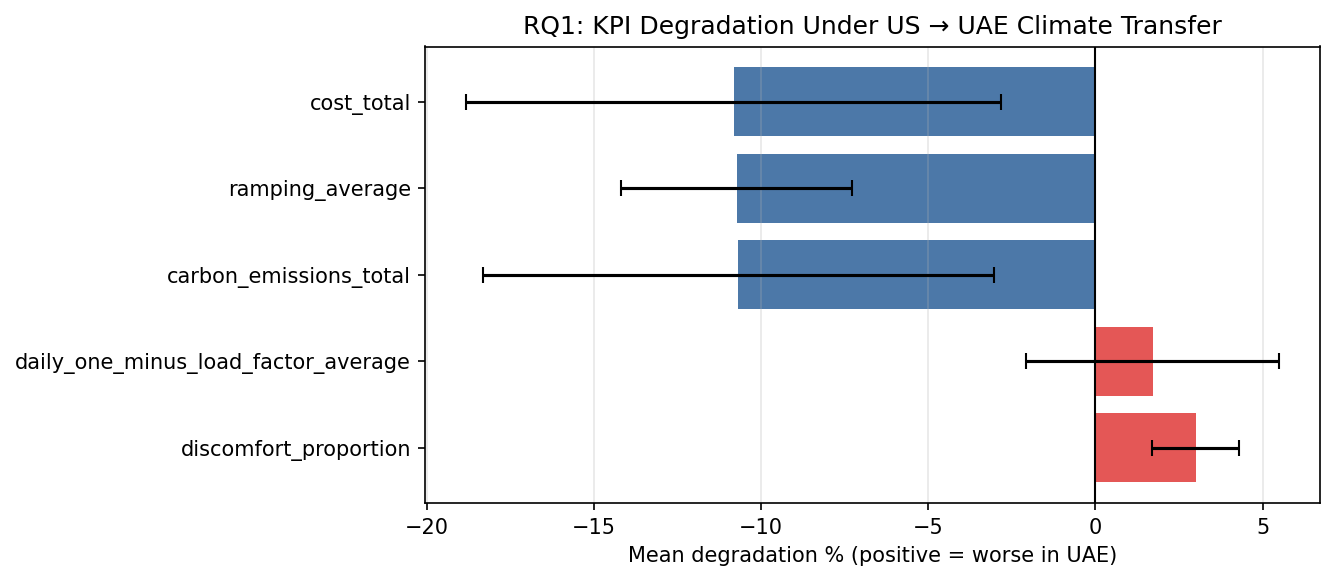

In [3]:
deg_cols = {k: f"{k}_degradation_pct" for k in KPI_NAMES}
mean_deg = {k: deg_df[v].mean() for k,v in deg_cols.items() if v in deg_df.columns}
std_deg  = {k: deg_df[v].std()  for k,v in deg_cols.items() if v in deg_df.columns}

rq1 = pd.DataFrame({"KPI": list(mean_deg.keys()),
                     "mean_degradation_pct": list(mean_deg.values()),
                     "std_degradation_pct":  list(std_deg.values())
                    }).sort_values("mean_degradation_pct", ascending=False)
rq1.to_csv("results_step5/rq1_kpi_degradation_summary.csv", index=False)

print("=== Mean KPI degradation across all 6 conditions ===")
print("(positive = worse in UAE, negative = improved in UAE)")
display(rq1.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#E45756" if v > 0 else "#4C78A8" for v in rq1["mean_degradation_pct"]]
ax.barh(rq1["KPI"], rq1["mean_degradation_pct"], color=colors,
        xerr=rq1["std_degradation_pct"], capsize=4)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Mean degradation % (positive = worse in UAE)")
ax.set_title("RQ1: KPI Degradation Under US → UAE Climate Transfer")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("results_step5/rq1_kpi_degradation.png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image("results_step5/rq1_kpi_degradation.png"))


## 3 · Research Question 2 — Does Reward Shaping Reduce Degradation?

Compare degradation rates across the three reward designs.


=== Mean degradation by reward design ===


,cost_total,carbon_emissions_total,discomfort_proportion,ramping_average,daily_one_minus_load_factor_average
reward_mode,,,,,
flat_shared,-9.535,-9.775,3.835,-14.415,0.055
local_individual,-11.355,-11.140,2.050,-8.465,2.565
uae_weighted,-11.560,-11.135,3.110,-9.290,2.520


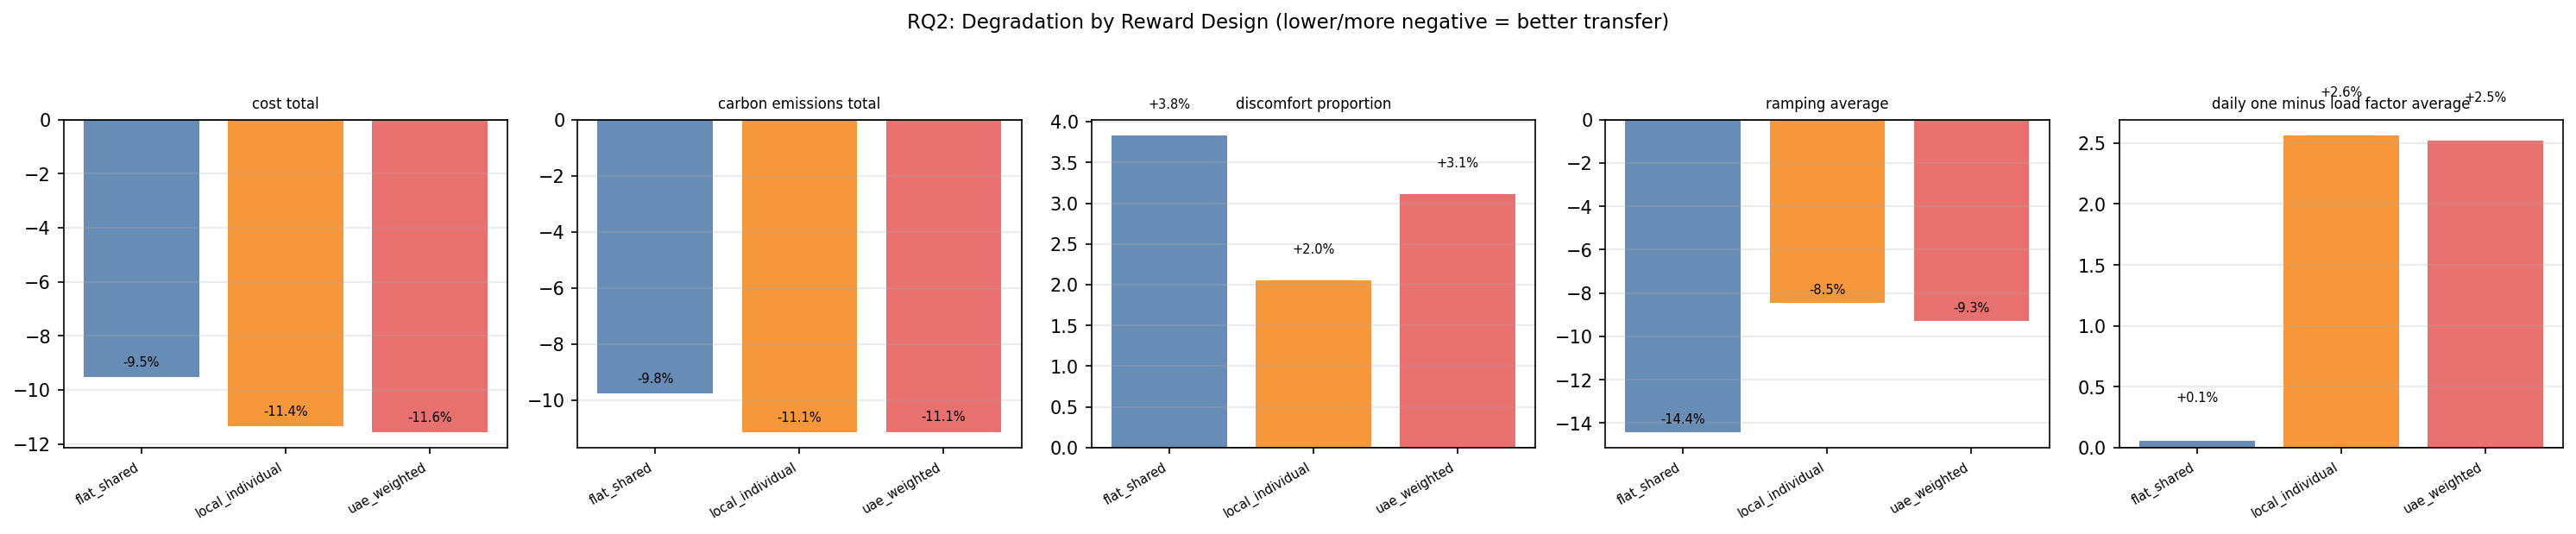

In [4]:
rq2_rows = []
for rm in ["flat_shared","local_individual","uae_weighted"]:
    sub = deg_df[deg_df["reward_mode"]==rm]
    row = {"reward_mode": rm}
    for k, col in deg_cols.items():
        if col in sub.columns:
            row[k] = round(sub[col].mean(), 3)
    rq2_rows.append(row)
rq2 = pd.DataFrame(rq2_rows)
rq2.to_csv("results_step5/rq2_reward_design_degradation.csv", index=False)

print("=== Mean degradation by reward design ===")
display(rq2.set_index("reward_mode"))

fig, axes = plt.subplots(1, len(KPI_NAMES), figsize=(20, 4))
rm_colors = {"flat_shared":"#4C78A8","local_individual":"#F58518","uae_weighted":"#E45756"}
for ax, kpi in zip(axes, KPI_NAMES):
    vals = [rq2[rq2["reward_mode"]==rm][kpi].iloc[0]
            if kpi in rq2.columns else 0 for rm in rm_colors]
    bars = ax.bar(list(rm_colors.keys()), vals,
                  color=list(rm_colors.values()), alpha=0.85)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(kpi.replace("_"," "), fontsize=8)
    ax.set_xticklabels(list(rm_colors.keys()), rotation=30, ha="right", fontsize=7)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f"{val:+.1f}%", ha="center", va="bottom", fontsize=7)
plt.suptitle("RQ2: Degradation by Reward Design (lower/more negative = better transfer)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("results_step5/rq2_reward_design_comparison.png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image("results_step5/rq2_reward_design_comparison.png"))


## 4 · Research Question 3 — MAPPO vs IPPO Under Climate Transfer


=== Mean degradation by algorithm ===


,cost_total,carbon_emissions_total,discomfort_proportion,ramping_average,daily_one_minus_load_factor_average
algorithm,,,,,
ippo,-17.870,-17.497,3.817,-9.523,4.907
mappo,-3.763,-3.870,2.180,-11.923,-1.480


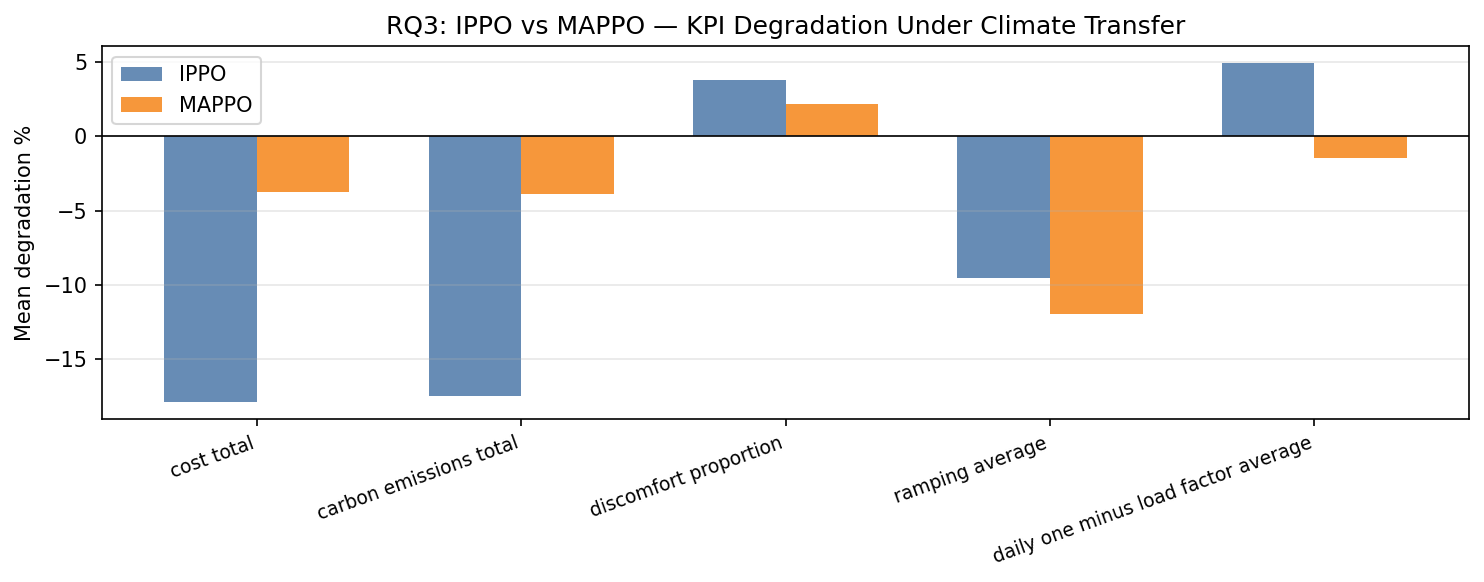

In [5]:
rq3_rows = []
for algo in ["ippo","mappo"]:
    sub = deg_df[deg_df["algorithm"]==algo]
    row = {"algorithm": algo}
    for k, col in deg_cols.items():
        if col in sub.columns:
            row[k] = round(sub[col].mean(), 3)
    rq3_rows.append(row)
rq3 = pd.DataFrame(rq3_rows)
rq3.to_csv("results_step5/rq3_algorithm_degradation.csv", index=False)

print("=== Mean degradation by algorithm ===")
display(rq3.set_index("algorithm"))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(KPI_NAMES)); w = 0.35
ippo_vals = [rq3[rq3["algorithm"]=="ippo"][k].iloc[0] if k in rq3.columns else 0 for k in KPI_NAMES]
mappo_vals= [rq3[rq3["algorithm"]=="mappo"][k].iloc[0] if k in rq3.columns else 0 for k in KPI_NAMES]
ax.bar(x-w/2, ippo_vals,  w, label="IPPO",  color="#4C78A8", alpha=0.85)
ax.bar(x+w/2, mappo_vals, w, label="MAPPO", color="#F58518", alpha=0.85)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([k.replace("_"," ") for k in KPI_NAMES],
                                       rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Mean degradation %"); ax.legend()
ax.set_title("RQ3: IPPO vs MAPPO — KPI Degradation Under Climate Transfer")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("results_step5/rq3_ippo_vs_mappo.png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image("results_step5/rq3_ippo_vs_mappo.png"))


## 5 · Reward Transfer Score (RTS)

RTS measures whether the reward signal faithfully reflects KPI changes
under climate transfer.

**Definition:**
- `Δreward_i` = normalised reward change for condition i (US → UAE)
- `ΔKPI_composite_i` = mean of normalised KPI degradations for condition i
- **RTS** = Pearson correlation between `Δreward` and `ΔKPI_composite` across conditions

**Interpretation:**
- RTS ≈ +1 → reward and KPI move together (well-aligned, reward transfers well)
- RTS ≈ 0 → reward is uninformative about KPI under climate shift
- RTS < 0 → reward and KPI diverge (reward misalignment: agent appears to do well but KPIs worsen)


Overall RTS (Pearson r): -0.0226  (p=0.9662)

Per-condition reward vs KPI change:


,algorithm,reward_mode,reward_delta_pct,kpi_composite_delta_pct
0,ippo,flat_shared,-405.732,-7.940
1,ippo,local_individual,0.543,-6.668
2,ippo,uae_weighted,-392.523,-7.092
3,mappo,flat_shared,-483.119,-3.994
4,mappo,local_individual,-12.319,-3.870
5,mappo,uae_weighted,-444.565,-3.450


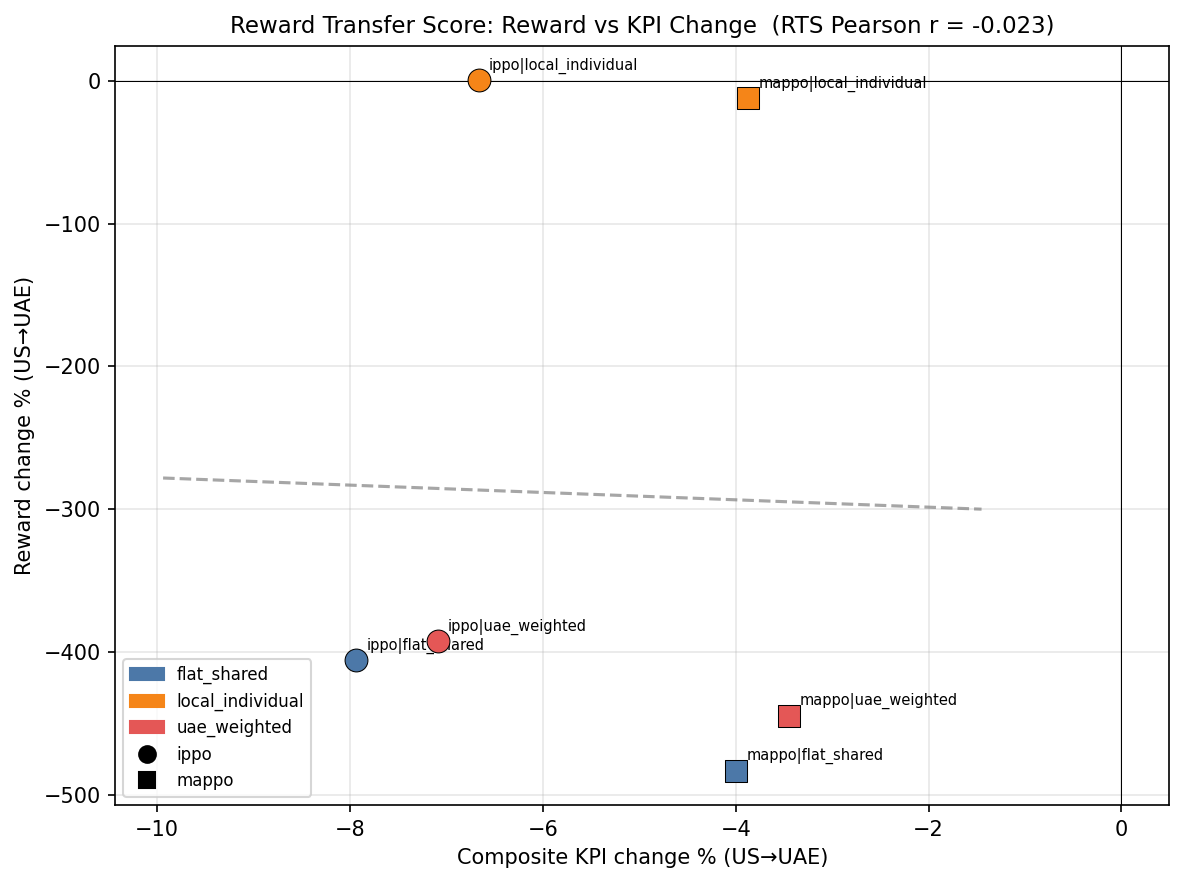

In [6]:
# Merge US and UAE rewards
us_r  = us_rewards.set_index(["algorithm","reward_mode"])["mean_agent_reward"]
uae_r = uae_rewards.set_index(["algorithm","reward_mode"])["mean_agent_reward"]

rts_rows = []
delta_rewards, delta_kpis = [], []

for algo, rm in CONDITIONS:
    key = (algo, rm)
    if key not in us_r.index or key not in uae_r.index:
        continue
    r_us  = float(us_r[key]); r_uae = float(uae_r[key])
    r_delta = (r_uae - r_us) / abs(r_us) * 100  # % reward change

    # Composite KPI degradation (mean across KPIs)
    row_deg = deg_df[(deg_df["algorithm"]==algo)&(deg_df["reward_mode"]==rm)]
    kpi_deltas = [float(row_deg[col].iloc[0]) for col in deg_cols.values()
                  if col in row_deg.columns and len(row_deg)]
    k_delta = float(np.mean(kpi_deltas)) if kpi_deltas else 0.

    delta_rewards.append(r_delta); delta_kpis.append(k_delta)
    rts_rows.append({"algorithm":algo,"reward_mode":rm,
                     "reward_delta_pct":round(r_delta,3),
                     "kpi_composite_delta_pct":round(k_delta,3)})

rts_df = pd.DataFrame(rts_rows)

# Overall RTS = Pearson r between Δreward and ΔKPIs
if len(delta_rewards) > 2:
    rts_r, rts_p = stats.pearsonr(delta_rewards, delta_kpis)
else:
    rts_r, rts_p = float("nan"), float("nan")

print(f"Overall RTS (Pearson r): {rts_r:.4f}  (p={rts_p:.4f})")
print()
print("Per-condition reward vs KPI change:")
display(rts_df.round(3))
rts_df.to_csv("results_step5/rts_per_condition.csv", index=False)
pd.DataFrame([{"RTS_pearson_r":round(rts_r,4),"p_value":round(rts_p,4)}]
             ).to_csv("results_step5/rts_summary.csv",index=False)

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
colors_map = {"flat_shared":"#4C78A8","local_individual":"#F58518","uae_weighted":"#E45756"}
markers_map = {"ippo":"o","mappo":"s"}
for _, row in rts_df.iterrows():
    ax.scatter(row["kpi_composite_delta_pct"], row["reward_delta_pct"],
               c=colors_map[row["reward_mode"]], marker=markers_map[row["algorithm"]],
               s=120, zorder=3, edgecolors="black", lw=0.5)
    ax.annotate(f"{row['algorithm']}|{row['reward_mode']}",
                (row["kpi_composite_delta_pct"], row["reward_delta_pct"]),
                textcoords="offset points", xytext=(5,5), fontsize=7)

if len(delta_rewards) > 2 and not np.isnan(rts_r):
    m,b = np.polyfit(delta_kpis, delta_rewards, 1)
    xr = np.linspace(min(delta_kpis)-2, max(delta_kpis)+2, 50)
    ax.plot(xr, m*xr+b, "--", color="gray", alpha=0.7,
            label=f"fit  r={rts_r:.3f}  p={rts_p:.3f}")

ax.axhline(0, color="black", lw=0.5); ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Composite KPI change % (US→UAE)", fontsize=10)
ax.set_ylabel("Reward change % (US→UAE)", fontsize=10)
ax.set_title("Reward Transfer Score: Reward vs KPI Change  (RTS Pearson r = %.3f)" % rts_r,
             fontsize=11)
legend_patches = [mpatches.Patch(color=v, label=k) for k,v in colors_map.items()]
legend_markers = [plt.Line2D([0],[0],marker=m,color="black",label=a,linestyle="None",markersize=8)
                  for a,m in markers_map.items()]
ax.legend(handles=legend_patches+legend_markers, fontsize=8, loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results_step5/rts_scatter.png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image("results_step5/rts_scatter.png"))


## 6 · Seasonal Breakdown

Evaluates all 6 conditions across 4 Dubai climate quarters to capture
seasonal variation in climate-transfer performance.

| Season | Months | Dubai temp range |
|--------|--------|-----------------|
| Q1 Winter | Jan–Mar | ~12–32 °C |
| Q2 Spring | Apr–Jun | ~22–42 °C |
| Q3 Summer | Jul–Sep | ~30–47 °C  ← peak heat |
| Q4 Autumn | Oct–Dec | ~20–38 °C |


In [7]:
EPW_URL = "https://climate.onebuilding.org/WMO_Region_2_Asia/ARE_United_Arab_Emirates/ARE_DU_Dubai.Intl.AP.411940_TMYx.2007-2021.zip"
EPW_ZIP = Path("/tmp/dubai_tmyx_seasonal.zip")
EPW_DIR = Path("/tmp/dubai_tmyx_seasonal")
EPW_FILE= EPW_DIR / "ARE_DU_Dubai.Intl.AP.411940_TMYx.2007-2021.epw"

if not EPW_FILE.exists():
    print("Downloading Dubai TMYx EPW...")
    urllib.request.urlretrieve(EPW_URL, EPW_ZIP)
    EPW_DIR.mkdir(exist_ok=True)
    import zipfile as zf
    with zf.ZipFile(EPW_ZIP) as z:
        z.extractall(EPW_DIR)
    print("Downloaded and extracted.")
else:
    print("EPW already cached.")

# Parse EPW
with open(EPW_FILE) as f:
    lines = f.readlines()[8:]
rows = [l.strip().split(",") for l in lines]
df_epw = pd.DataFrame(rows)
dry_bulb = df_epw[6].astype(float).values
rel_hum  = df_epw[8].astype(float).values
direct   = df_epw[13].astype(float).values
diffuse  = df_epw[15].astype(float).values

# Quarter start hours (month boundaries)
month_starts = [0, 744, 1416, 2160, 2880, 3624, 4344, 5088, 5832, 6552, 7272, 7992]
N = 2208  # rows needed by CityLearn
SEASONS = {
    "Q1_winter": month_starts[0],   # Jan–Apr3
    "Q2_spring": month_starts[3],   # Apr–Jul3
    "Q3_summer": month_starts[6],   # Jul–Sep30
    "Q4_autumn": month_starts[9],   # Oct–Dec31
}

US_CACHE = Path.home() / "Library/Caches/citylearn/v2.5.0/datasets/citylearn_challenge_2023_phase_3_1"

def make_seasonal_weather(arr, start, n=N):
    s = arr[start:start+n]
    p1=np.roll(s,-1); p1[-1]=p1[-2]
    p2=np.roll(s,-2); p2[-2:]=p2[-3]
    p3=np.roll(s,-3); p3[-3:]=p3[-4]
    return s,p1,p2,p3

season_schemas = {}
for season, start in SEASONS.items():
    t,t1,t2,t3 = make_seasonal_weather(dry_bulb, start)
    h,h1,h2,h3 = make_seasonal_weather(rel_hum,  start)
    d,d1,d2,d3 = make_seasonal_weather(diffuse,  start)
    r,r1,r2,r3 = make_seasonal_weather(direct,   start)
    wdf = pd.DataFrame({
        "outdoor_dry_bulb_temperature":t,"outdoor_relative_humidity":h,
        "diffuse_solar_irradiance":d,"direct_solar_irradiance":r,
        "outdoor_dry_bulb_temperature_predicted_1":t1,
        "outdoor_dry_bulb_temperature_predicted_2":t2,
        "outdoor_dry_bulb_temperature_predicted_3":t3,
        "outdoor_relative_humidity_predicted_1":h1,
        "outdoor_relative_humidity_predicted_2":h2,
        "outdoor_relative_humidity_predicted_3":h3,
        "diffuse_solar_irradiance_predicted_1":d1,
        "diffuse_solar_irradiance_predicted_2":d2,
        "diffuse_solar_irradiance_predicted_3":d3,
        "direct_solar_irradiance_predicted_1":r1,
        "direct_solar_irradiance_predicted_2":r2,
        "direct_solar_irradiance_predicted_3":r3,
    })
    dst = Path(f"citylearn_uae_{season}")
    if dst.exists(): shutil.rmtree(dst)
    shutil.copytree(US_CACHE, dst)
    wdf.to_csv(dst/"weather.csv", index=False)
    schema_p = dst/"schema.json"
    with open(schema_p) as f2: sch=json.load(f2)
    sch["root_directory"]=str(dst.resolve())
    with open(schema_p,"w") as f2: json.dump(sch,f2)
    season_schemas[season] = str(schema_p)
    print(f"  {season}: temp {t.min():.0f}–{t.max():.0f} °C  mean={t.mean():.1f} °C")

print("Seasonal schemas ready.")


EPW already cached.


  Q1_winter: temp 12–36 °C  mean=22.6 °C
  Q2_spring: temp 21–45 °C  mean=32.3 °C
  Q3_summer: temp 27–47 °C  mean=36.0 °C
  Q4_autumn: temp 14–40 °C  mean=26.8 °C
Seasonal schemas ready.


In [8]:
# Reward functions (reuse from UAE eval)
DEFAULT_FLAT_WEIGHTS = {"discomfort":0.10,"electricity":0.10,"ramping":0.10,"solar":0.10}
UAE_WEIGHTED_WEIGHTS = {"discomfort":0.140,"electricity":0.120,"ramping":0.060,"solar":0.080}

class ProjectReward(RewardFunction):
    def __init__(self,e=None,w=None,shared=True,**_):
        super().__init__(e); self.weights=dict(DEFAULT_FLAT_WEIGHTS if w is None else w)
        self.shared=shared; self.pd=None; self.pl=None
    def calculate(self,observations):
        cs=[self._c(o) for o in observations]
        de=float(sum(c["electricity"] for c in cs))
        dr=0. if self.pd is None else abs(de-self.pd); self.pd=de
        le=[c["electricity"] for c in cs]
        lr=([0.]*len(le) if self.pl is None else [abs(a-b) for a,b in zip(le,self.pl)])
        self.pl=le
        if self.shared:
            dc={"discomfort":float(sum(c["discomfort"] for c in cs)),"electricity":de,
                "ramping":dr,"solar":float(sum(c["solar"] for c in cs))}
            r=-self._w(dc); return [r]*len(observations)
        return [-self._w({**c,"ramping":lr[i]}) for i,c in enumerate(cs)]
    def reset_memory(self): self.pd=None; self.pl=None
    def _c(self,o):
        net=float(o.get("net_electricity_consumption",0.)); imp=max(net,0.)
        sol=max(float(o.get("solar_generation",0.)),0.)
        return {"discomfort":self._d(o),"electricity":imp,"ramping":0.,
                "solar":imp if sol>0. else 0.}
    def _d(self,o):
        if "average_unmet_cooling_setpoint_difference" in o:
            return max(float(o["average_unmet_cooling_setpoint_difference"]),0.)
        if "indoor_dry_bulb_temperature_delta" in o:
            return abs(float(o["indoor_dry_bulb_temperature_delta"]))
        t=float(o.get("indoor_dry_bulb_temperature",0.))
        return abs(t-float(o.get("indoor_dry_bulb_temperature_set_point",t)))
    def _w(self,c): return float(sum(self.weights[k]*c[k] for k in self.weights))

class FlatSharedReward(ProjectReward):
    def __init__(self,e=None,**kw): super().__init__(e,DEFAULT_FLAT_WEIGHTS,True,**kw)
class LocalIndividualReward(ProjectReward):
    def __init__(self,e=None,**kw): super().__init__(e,DEFAULT_FLAT_WEIGHTS,False,**kw)
class UAEWeightedSharedReward(ProjectReward):
    def __init__(self,e=None,**kw): super().__init__(e,UAE_WEIGHTED_WEIGHTS,True,**kw)
REWARD_FUNCTIONS={"flat_shared":FlatSharedReward,"local_individual":LocalIndividualReward,"uae_weighted":UAEWeightedSharedReward}

def _box(sp): return gym.spaces.Box(np.asarray(sp.low,np.float32),np.asarray(sp.high,np.float32),sp.shape,np.float32)
def _neu(sp): return np.clip(np.zeros(sp.shape,np.float32),sp.low,sp.high)

class MARLEnv:
    def __init__(self,schema,rm="flat_shared",seed=None,safety=0.75):
        self.safety=safety
        self.base=CityLearnEnv(schema,reward_function=REWARD_FUNCTIONS[rm],central_agent=False,random_seed=seed)
        self.agents=[b.name for b in self.base.buildings]
        self.nas={a:_box(sp) for a,sp in zip(self.agents,self.base.action_space)}
        self.obs_s={a:_box(sp) for a,sp in zip(self.agents,self.base.observation_space)}
        self.act_s={a:gym.spaces.Box(-1.,1.,sp.shape,np.float32) for a,sp in self.nas.items()}
        self._obs=None
    def reset(self,seed=None):
        if seed: np.random.seed(seed)
        r=self.base.reset(); obs,info=(r if isinstance(r,tuple) and len(r)==2 else (r,{}))
        if hasattr(self.base.reward_function,"reset_memory"): self.base.reward_function.reset_memory()
        self._obs={a:np.asarray(list(o.values()) if isinstance(o,dict) else o,np.float32).reshape(-1)
                   for a,o in zip(self.agents,obs)}; return self._obs,{}
    def step(self,actions):
        acts=[]
        for a in self.agents:
            ac=np.clip(np.asarray(actions[a],np.float32).reshape(-1),-1.,1.)
            ns=self.nas[a]; neu=_neu(ns)
            ac=neu+self.safety*np.where(ac>=0,ac*(ns.high-neu),ac*(neu-ns.low))
            acts.append(np.clip(ac,ns.low,ns.high).astype(np.float32))
        try: r=self.base.step(acts)
        except: r=self.base.step([_neu(self.nas[a]) for a in self.agents])
        obs,rws,term,trunc,info=(r if len(r)==5 else (*r[:2],bool(r[2]),False,r[3]))
        self._obs={a:np.asarray(list(o.values()) if isinstance(o,dict) else o,np.float32).reshape(-1)
                   for a,o in zip(self.agents,obs)}
        rwd={a:float(v) for a,v in zip(self.agents,rws if len(rws)>1 else rws*len(self.agents))}
        return self._obs,rwd,{a:bool(term) for a in self.agents},{a:bool(trunc) for a in self.agents},{}
    def kpis(self):
        df=pd.DataFrame(self.base.evaluate())
        if {"level","cost_function","value"}.issubset(df.columns):
            d=df[df["level"]=="district"]
            return d[d["cost_function"].isin(KPI_NAMES)][["cost_function","value"]].reset_index(drop=True)
        return df
    def close(self):
        fn=getattr(self.base,"close",None);
        if callable(fn): fn()

# Load 250k models
def layer_init(l,std=math.sqrt(2),b=0.):
    nn.init.orthogonal_(l.weight,std); nn.init.constant_(l.bias,b); return l
def mlp(i,o,h,os=1.):
    return nn.Sequential(layer_init(nn.Linear(i,h)),nn.Tanh(),layer_init(nn.Linear(h,h)),nn.Tanh(),layer_init(nn.Linear(h,o),std=os))
def atanh(x): return 0.5*(torch.log1p(torch.clamp(x,-0.999999,0.999999))-torch.log1p(-torch.clamp(x,-0.999999,0.999999)))

class RunNorm:
    def __init__(self,shape,eps=1e-8,clip=10.):
        self.mean=np.zeros(shape,np.float64); self.var=np.ones(shape,np.float64); self.eps=eps; self.clip=clip
    def normalize(self,x):
        return np.clip((x-self.mean)/np.sqrt(self.var+self.eps),-self.clip,self.clip).astype(np.float32)

class SGA(nn.Module):
    def __init__(self,od,ad,h):
        super().__init__(); self.mean_net=mlp(od,ad,h,0.01); self.log_std=nn.Parameter(torch.zeros(ad))
    def deterministic(self,o): return torch.tanh(self.mean_net(o))
class IPPO(nn.Module):
    def __init__(self,od,ad,h): super().__init__(); self.actor=SGA(od,ad,h); self.critic=mlp(od,1,h)
class CC(nn.Module):
    def __init__(self,sd,h): super().__init__(); self.net=mlp(sd,1,h)
    def forward(self,s): return self.net(s).squeeze(-1)

def to_t(x): return torch.as_tensor(x,dtype=torch.float32,device=DEVICE)

_tmp_env = MARLEnv(list(season_schemas.values())[0], seed=42)
_obs,_=_tmp_env.reset(seed=42)
AGENTS=_tmp_env.agents; OBS_DIM=_obs[AGENTS[0]].shape[0]
ACT_DIM=_tmp_env.act_s[AGENTS[0]].shape[0]
STATE_DIM=np.concatenate([_obs[a] for a in AGENTS]).shape[0]
_tmp_env.close()
HIDDEN=256

loaded={}
for algo,rm in CONDITIONS:
    cp=Path("models")/f"{algo}_{rm}_250k.pt"
    ck=torch.load(cp,map_location=DEVICE,weights_only=False)
    norms={a:RunNorm(OBS_DIM) for a in AGENTS}
    for a in AGENTS: norms[a].mean=ck["norm_means"][a]; norms[a].var=ck["norm_vars"][a]
    if algo=="ippo":
        pol=nn.ModuleDict({a:IPPO(OBS_DIM,ACT_DIM,HIDDEN).to(DEVICE) for a in AGENTS})
        pol.load_state_dict(ck["state_dict"]); pol.eval()
        loaded[(algo,rm)]={"type":"ippo","pol":pol,"norms":norms}
    else:
        act=nn.ModuleDict({a:SGA(OBS_DIM,ACT_DIM,HIDDEN).to(DEVICE) for a in AGENTS})
        act.load_state_dict(ck["actor_state_dict"]); act.eval()
        loaded[(algo,rm)]={"type":"mappo","act":act,"norms":norms}

print(f"Loaded {len(loaded)} models. agents={len(AGENTS)} obs={OBS_DIM} act={ACT_DIM}")


Loaded 6 models. agents=6 obs=30 act=3


In [9]:
@torch.no_grad()
def get_acts(algo,rm,obs):
    m=loaded[(algo,rm)]; norms=m["norms"]
    if m["type"]=="ippo":
        return {a:m["pol"][a].actor.deterministic(to_t(norms[a].normalize(obs[a])).unsqueeze(0)).squeeze(0).cpu().numpy().astype(np.float32) for a in AGENTS}
    return {a:m["act"][a].deterministic(to_t(norms[a].normalize(obs[a])).unsqueeze(0)).squeeze(0).cpu().numpy().astype(np.float32) for a in AGENTS}

def eval_seasonal(algo,rm,schema,seed=199):
    env_rm="flat_shared" if algo=="neutral" else rm
    env=MARLEnv(schema,rm=env_rm,seed=seed)
    obs,_=env.reset(seed=seed)
    cum={a:0. for a in AGENTS}
    for step in range(1,2209):
        acts=({a:np.zeros(env.act_s[a].shape,np.float32) for a in AGENTS} if algo=="neutral"
               else get_acts(algo,rm,obs))
        obs,rws,tms,trs,_=env.step(acts)
        for a,r in rws.items(): cum[a]+=float(r)
        if any(tms.values()) or any(trs.values()): break
    mean=float(np.mean(list(cum.values())))
    try: kpis=env.kpis()
    except: kpis=pd.DataFrame()
    env.close()
    return mean, kpis

seasonal_results=[]
all_season_kpis=[]
print("Running seasonal evaluations (28 runs)...")
for season,schema in season_schemas.items():
    print(f"  Season: {season}")
    # neutral
    mean,kpis=eval_seasonal("neutral","neutral",schema)
    row={"season":season,"algorithm":"neutral","reward_mode":"neutral","mean_reward":mean}
    if not kpis.empty:
        for _,r in kpis.iterrows(): row[r["cost_function"]]=r["value"]
    seasonal_results.append(row)

    for algo,rm in CONDITIONS:
        mean,kpis=eval_seasonal(algo,rm,schema)
        row={"season":season,"algorithm":algo,"reward_mode":rm,"mean_reward":mean}
        if not kpis.empty:
            for _,r in kpis.iterrows(): row[r["cost_function"]]=r["value"]
        seasonal_results.append(row)
    print(f"    done.")

seasonal_df=pd.DataFrame(seasonal_results)
seasonal_df.to_csv("results_step5/seasonal_kpis.csv",index=False)
print("Seasonal evaluation complete.")
display(seasonal_df[["season","algorithm","reward_mode","mean_reward","discomfort_proportion","cost_total"]].round(3))


Running seasonal evaluations (28 runs)...
  Season: Q1_winter


    done.
  Season: Q2_spring


    done.
  Season: Q3_summer


    done.
  Season: Q4_autumn


    done.
Seasonal evaluation complete.


,season,algorithm,reward_mode,mean_reward,discomfort_proportion,cost_total
0,Q1_winter,neutral,neutral,-1423.256,0.651,0.487
1,Q1_winter,ippo,flat_shared,-1749.988,0.693,0.693
2,Q1_winter,ippo,local_individual,-271.198,0.639,0.511
3,Q1_winter,ippo,uae_weighted,-1699.238,0.692,0.692
4,Q1_winter,mappo,flat_shared,-1640.249,0.640,0.588
5,Q1_winter,mappo,local_individual,-289.894,0.663,0.543
6,Q1_winter,mappo,uae_weighted,-1555.602,0.648,0.577
7,Q2_spring,neutral,neutral,-1424.154,0.990,0.366
8,Q2_spring,ippo,flat_shared,-1584.863,0.985,0.438
9,Q2_spring,ippo,local_individual,-267.868,0.989,0.378


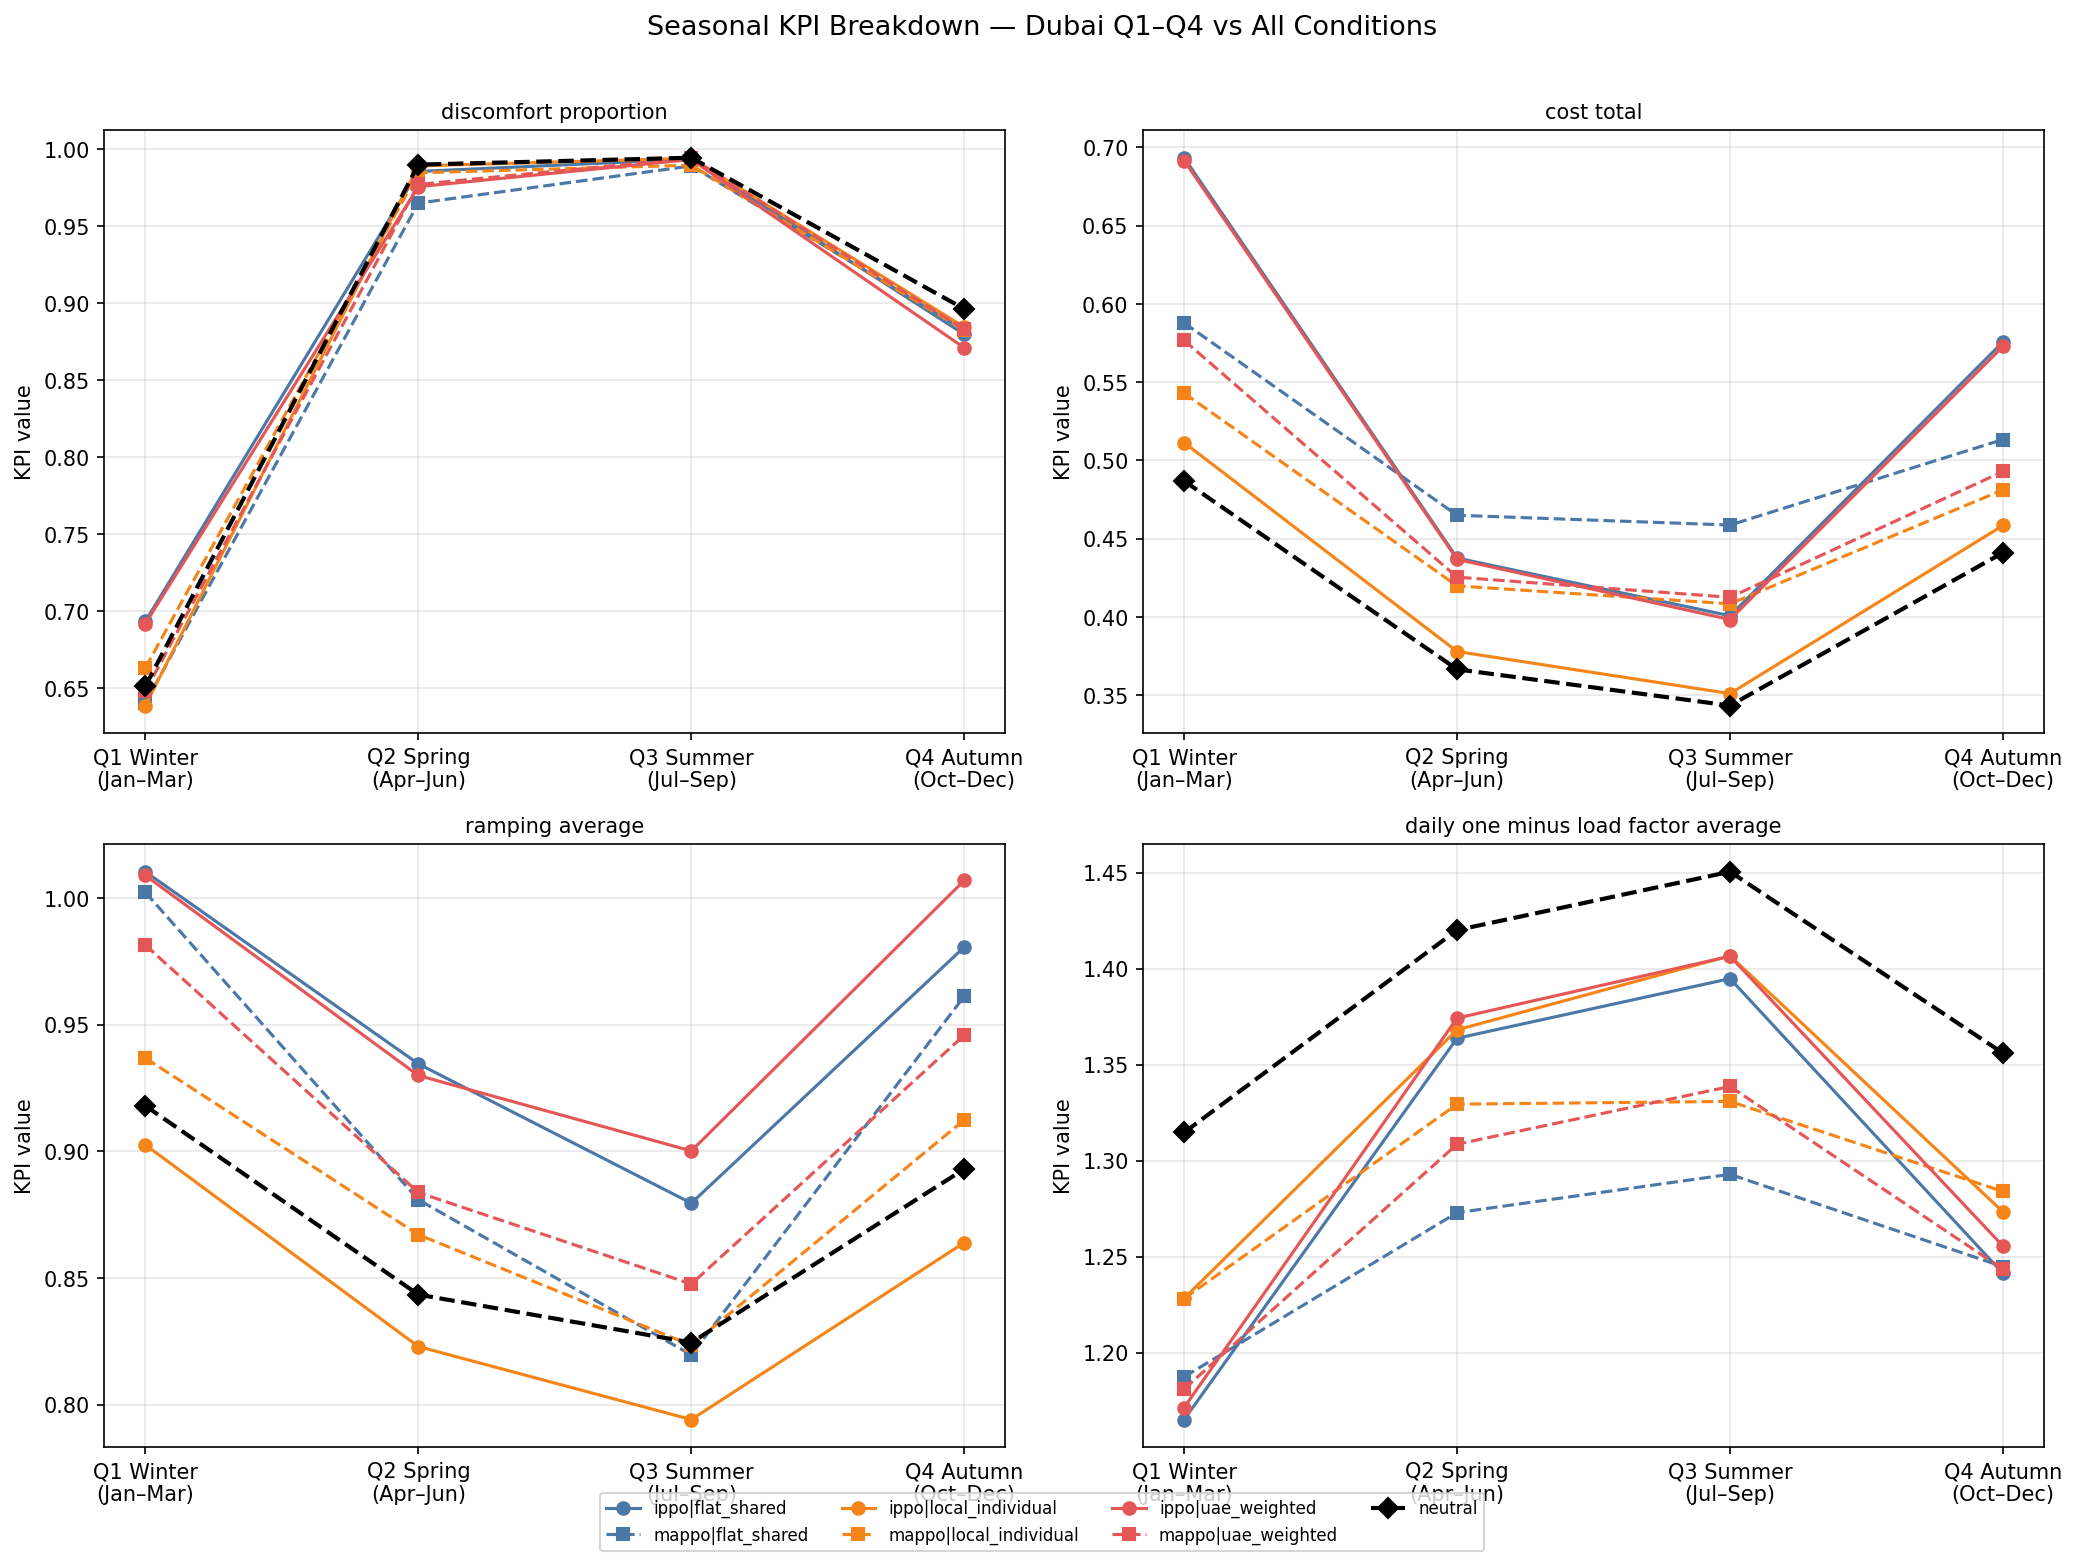

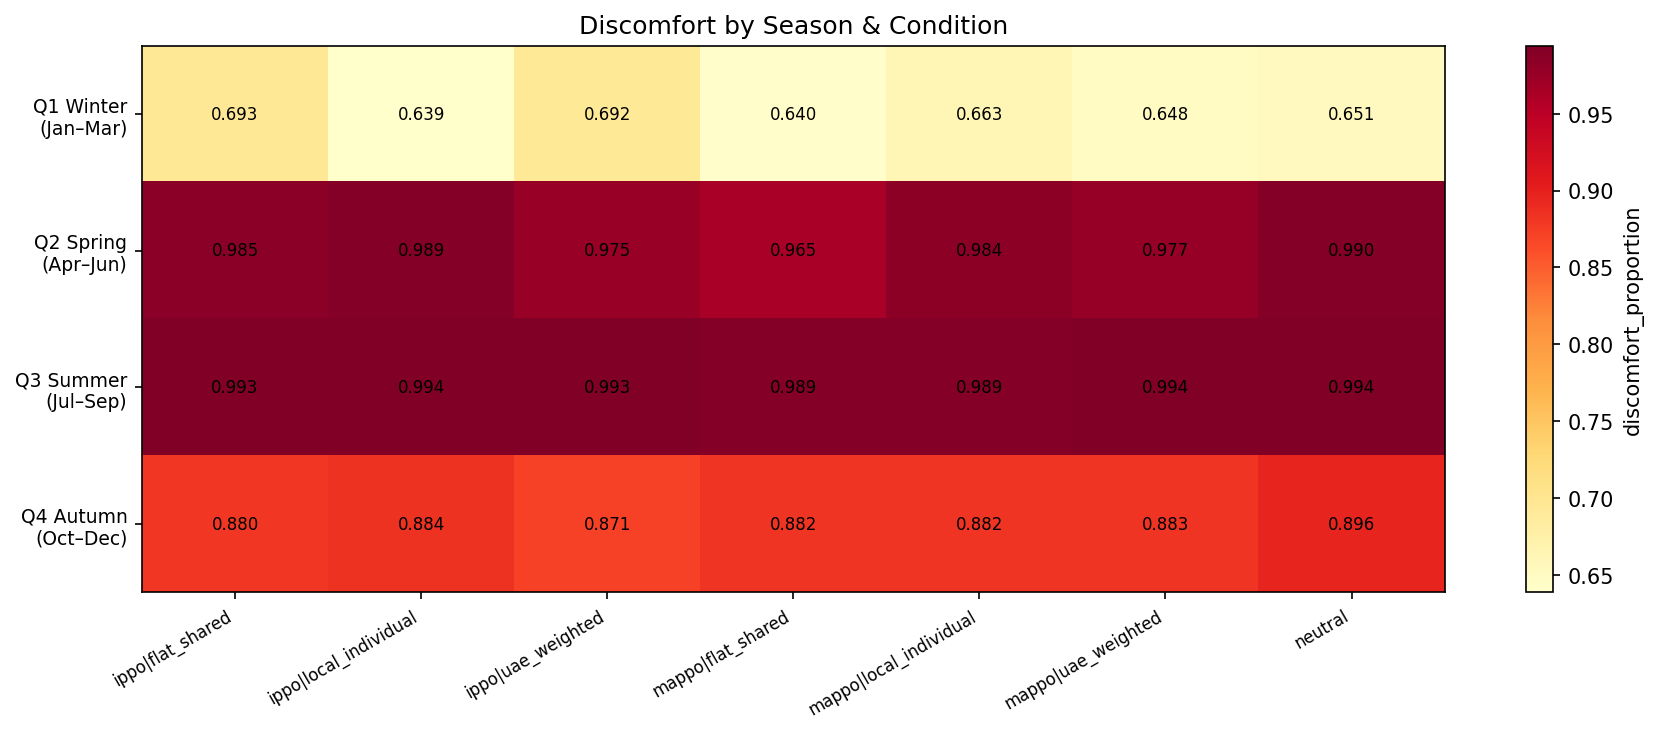

In [10]:
season_order=["Q1_winter","Q2_spring","Q3_summer","Q4_autumn"]
season_labels=["Q1 Winter\n(Jan–Mar)","Q2 Spring\n(Apr–Jun)","Q3 Summer\n(Jul–Sep)","Q4 Autumn\n(Oct–Dec)"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
kpis_to_plot = ["discomfort_proportion","cost_total","ramping_average","daily_one_minus_load_factor_average"]
colors_c = {"flat_shared":"#4C78A8","local_individual":"#F58518","uae_weighted":"#E45756"}

for ax, kpi in zip(axes.flatten(), kpis_to_plot):
    for rm in ["flat_shared","local_individual","uae_weighted"]:
        for algo,ls,mk in [("ippo","-","o"),("mappo","--","s")]:
            sub=seasonal_df[(seasonal_df["algorithm"]==algo)&(seasonal_df["reward_mode"]==rm)]
            vals=[sub[sub["season"]==s][kpi].iloc[0] if len(sub[sub["season"]==s]) and kpi in sub.columns else np.nan
                  for s in season_order]
            ax.plot(season_labels, vals, ls=ls, marker=mk, color=colors_c[rm],
                    label=f"{algo}|{rm}", lw=1.5, markersize=6)
    neutral_vals=[seasonal_df[(seasonal_df["algorithm"]=="neutral")&(seasonal_df["season"]==s)][kpi].iloc[0]
                  if len(seasonal_df[(seasonal_df["algorithm"]=="neutral")&(seasonal_df["season"]==s)]) and kpi in seasonal_df.columns else np.nan
                  for s in season_order]
    ax.plot(season_labels, neutral_vals, "k--", lw=2, label="neutral", marker="D", markersize=7)
    ax.set_title(kpi.replace("_"," "), fontsize=10)
    ax.grid(alpha=0.3); ax.set_ylabel("KPI value")

handles,labels=axes[0,0].get_legend_handles_labels()
fig.legend(handles,labels,loc="lower center",ncol=4,fontsize=8,bbox_to_anchor=(0.5,-0.02))
plt.suptitle("Seasonal KPI Breakdown — Dubai Q1–Q4 vs All Conditions", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("results_step5/seasonal_kpi_breakdown.png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image("results_step5/seasonal_kpi_breakdown.png"))

# Heatmap: season × condition for discomfort
fig2, ax2 = plt.subplots(figsize=(12, 5))
cond_labels=[f"{a}|{rm}" for a,rm in CONDITIONS]+["neutral"]
heat_data=[]
for s in season_order:
    row_vals=[]
    for algo,rm in CONDITIONS:
        sub=seasonal_df[(seasonal_df["season"]==s)&(seasonal_df["algorithm"]==algo)&(seasonal_df["reward_mode"]==rm)]
        row_vals.append(float(sub["discomfort_proportion"].iloc[0]) if len(sub) and "discomfort_proportion" in sub.columns else np.nan)
    sub_n=seasonal_df[(seasonal_df["season"]==s)&(seasonal_df["algorithm"]=="neutral")]
    row_vals.append(float(sub_n["discomfort_proportion"].iloc[0]) if len(sub_n) and "discomfort_proportion" in sub_n.columns else np.nan)
    heat_data.append(row_vals)
heat_arr=np.array(heat_data,dtype=float)
im=ax2.imshow(heat_arr,cmap="YlOrRd",aspect="auto")
ax2.set_xticks(range(len(cond_labels))); ax2.set_xticklabels(cond_labels,rotation=30,ha="right",fontsize=8)
ax2.set_yticks(range(len(season_order))); ax2.set_yticklabels(season_labels,fontsize=9)
for i in range(len(season_order)):
    for j in range(len(cond_labels)):
        if not np.isnan(heat_arr[i,j]):
            ax2.text(j,i,f"{heat_arr[i,j]:.3f}",ha="center",va="center",fontsize=8)
plt.colorbar(im,ax=ax2,label="discomfort_proportion"); ax2.set_title("Discomfort by Season & Condition")
plt.tight_layout()
plt.savefig("results_step5/seasonal_discomfort_heatmap.png",dpi=150,bbox_inches="tight")
plt.close(fig2)
display(Image("results_step5/seasonal_discomfort_heatmap.png"))


## 7 · Pareto Frontier Shift (RQ4)

The Pareto frontier shows the best achievable cost/discomfort trade-offs.
If the frontier shifts position under UAE climate, it means the fundamental
trade-off structure has changed — not just the numbers.


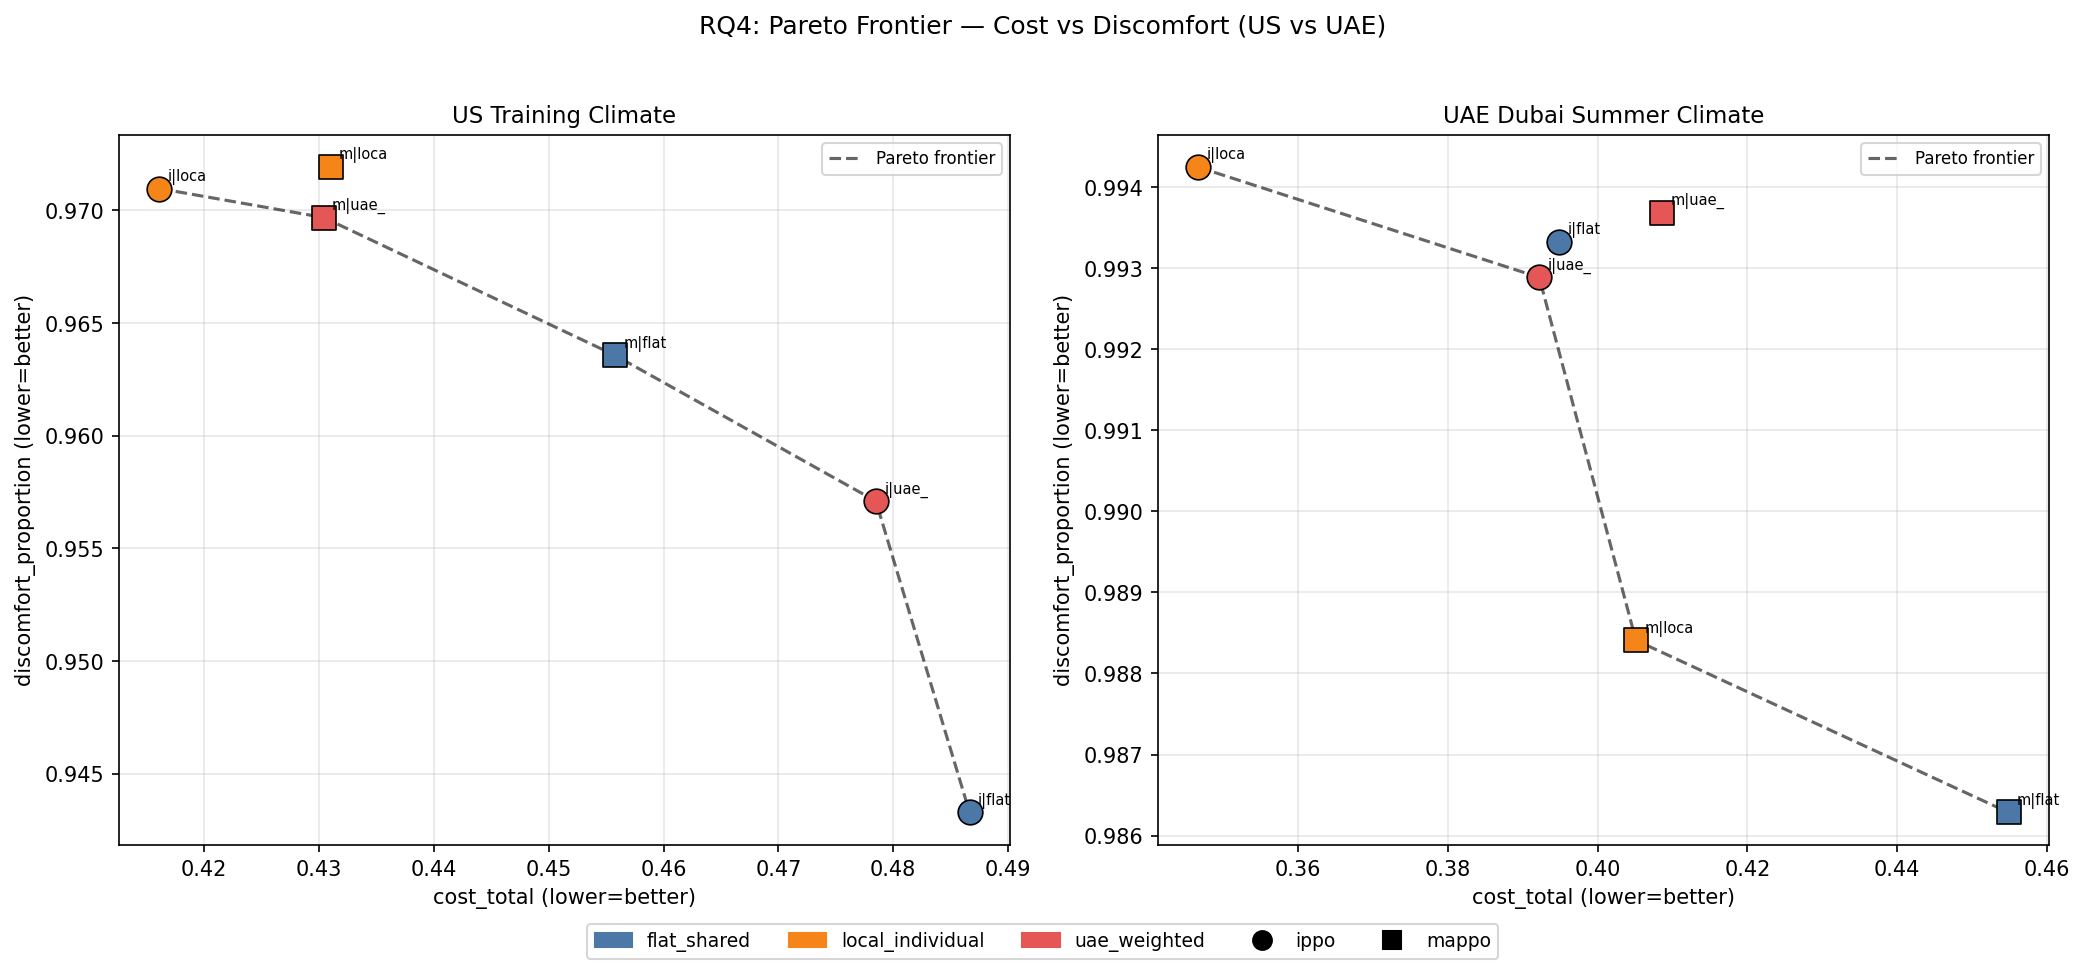

=== Pareto shift per condition ===


,condition,us_cost,us_discomfort,uae_cost,uae_discomfort,cost_shift,discomfort_shift,euclidean_shift
0,ippo|flat_shared,0.4866,0.9433,0.3948,0.9933,-0.0918,0.0501,0.1046
1,ippo|local_individual,0.4161,0.9710,0.3466,0.9942,-0.0695,0.0233,0.0733
2,ippo|uae_weighted,0.4785,0.9571,0.3922,0.9929,-0.0863,0.0358,0.0934
3,mappo|flat_shared,0.4558,0.9636,0.4549,0.9863,-0.0009,0.0227,0.0227
4,mappo|local_individual,0.4310,0.9719,0.4051,0.9884,-0.0259,0.0165,0.0307
5,mappo|uae_weighted,0.4304,0.9697,0.4086,0.9937,-0.0218,0.0240,0.0325


In [11]:
def pareto_front(points):
    pts=sorted(points, key=lambda x:x[0])
    front=[pts[0]]
    for p in pts[1:]:
        if p[1] <= front[-1][1]: front.append(p)
    return np.array(front)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rm_colors={"flat_shared":"#4C78A8","local_individual":"#F58518","uae_weighted":"#E45756"}
algo_markers={"ippo":"o","mappo":"s"}

for ax, (climate, kpis_data, title) in enumerate([
    ("US",  us_kpis,  "US Training Climate"),
    ("UAE", uae_kpis, "UAE Dubai Summer Climate"),
]):
    ax_obj=axes[ax]
    us_pts, uae_pts=[],[]
    for algo,rm in CONDITIONS:
        sub=kpis_data[(kpis_data["algorithm"]==algo)&(kpis_data["reward_mode"]==rm)]
        cost=sub[sub["cost_function"]=="cost_total"]["value"]
        disc=sub[sub["cost_function"]=="discomfort_proportion"]["value"]
        if len(cost) and len(disc):
            c,d=float(cost.iloc[0]),float(disc.iloc[0])
            ax_obj.scatter(c,d,color=rm_colors[rm],marker=algo_markers[algo],
                          s=140,zorder=3,edgecolors="black",lw=0.8)
            ax_obj.annotate(f"{algo[:1]}|{rm[:4]}",
                           (c,d),textcoords="offset points",xytext=(4,4),fontsize=7)
            if climate=="US": us_pts.append((c,d))
            else: uae_pts.append((c,d))

    pts=us_pts if climate=="US" else uae_pts
    if len(pts)>=2:
        try:
            front=pareto_front(pts)
            ax_obj.plot(front[:,0],front[:,1],"--",color="black",lw=1.5,alpha=0.6,label="Pareto frontier")
        except: pass

    ax_obj.set_xlabel("cost_total (lower=better)",fontsize=10)
    ax_obj.set_ylabel("discomfort_proportion (lower=better)",fontsize=10)
    ax_obj.set_title(title,fontsize=11); ax_obj.grid(alpha=0.3)
    ax_obj.legend(fontsize=8)

patches=[mpatches.Patch(color=v,label=k) for k,v in rm_colors.items()]
lms=[plt.Line2D([0],[0],marker=m,color="black",label=a,linestyle="None",markersize=9)
     for a,m in algo_markers.items()]
fig.legend(handles=patches+lms,loc="lower center",ncol=5,fontsize=9,bbox_to_anchor=(0.5,-0.04))
plt.suptitle("RQ4: Pareto Frontier — Cost vs Discomfort (US vs UAE)",fontsize=12,y=1.02)
plt.tight_layout()
plt.savefig("results_step5/pareto_frontier_shift.png",dpi=150,bbox_inches="tight")
plt.close(fig)
display(Image("results_step5/pareto_frontier_shift.png"))

# Compute Pareto frontier shift metric (mean distance between US and UAE frontiers)
us_cost =[ float(us_kpis[(us_kpis["algorithm"]==a)&(us_kpis["reward_mode"]==r)&(us_kpis["cost_function"]=="cost_total")]["value"].iloc[0]) for a,r in CONDITIONS]
us_disc =[ float(us_kpis[(us_kpis["algorithm"]==a)&(us_kpis["reward_mode"]==r)&(us_kpis["cost_function"]=="discomfort_proportion")]["value"].iloc[0]) for a,r in CONDITIONS]
uae_cost=[ float(uae_kpis[(uae_kpis["algorithm"]==a)&(uae_kpis["reward_mode"]==r)&(uae_kpis["cost_function"]=="cost_total")]["value"].iloc[0]) if len(uae_kpis[(uae_kpis["algorithm"]==a)&(uae_kpis["reward_mode"]==r)&(uae_kpis["cost_function"]=="cost_total")]) else np.nan for a,r in CONDITIONS]
uae_disc=[ float(uae_kpis[(uae_kpis["algorithm"]==a)&(uae_kpis["reward_mode"]==r)&(uae_kpis["cost_function"]=="discomfort_proportion")]["value"].iloc[0]) if len(uae_kpis[(uae_kpis["algorithm"]==a)&(uae_kpis["reward_mode"]==r)&(uae_kpis["cost_function"]=="discomfort_proportion")]) else np.nan for a,r in CONDITIONS]

pareto_df=pd.DataFrame({"condition":CONDITION_LABELS,
    "us_cost":us_cost,"us_discomfort":us_disc,
    "uae_cost":uae_cost,"uae_discomfort":uae_disc})
pareto_df["cost_shift"]=pareto_df["uae_cost"]-pareto_df["us_cost"]
pareto_df["discomfort_shift"]=pareto_df["uae_discomfort"]-pareto_df["us_discomfort"]
pareto_df["euclidean_shift"]=(pareto_df["cost_shift"]**2+pareto_df["discomfort_shift"]**2)**0.5
pareto_df.to_csv("results_step5/pareto_shift_analysis.csv",index=False)
print("=== Pareto shift per condition ===")
display(pareto_df.round(4))


## 8 · Report Summary Table

All four research questions answered in one table.


In [12]:
# Build master summary
summary_rows=[]
for algo,rm in CONDITIONS:
    row={"algorithm":algo,"reward_mode":rm}
    # US KPIs
    for kpi in ["cost_total","discomfort_proportion"]:
        v=us_kpis[(us_kpis["algorithm"]==algo)&(us_kpis["reward_mode"]==rm)&(us_kpis["cost_function"]==kpi)]["value"]
        row[f"us_{kpi}"]=round(float(v.iloc[0]),4) if len(v) else None
    # UAE KPIs
    for kpi in ["cost_total","discomfort_proportion"]:
        v=uae_kpis[(uae_kpis["algorithm"]==algo)&(uae_kpis["reward_mode"]==rm)&(uae_kpis["cost_function"]==kpi)]["value"]
        row[f"uae_{kpi}"]=round(float(v.iloc[0]),4) if len(v) else None
    # Degradation
    drow=deg_df[(deg_df["algorithm"]==algo)&(deg_df["reward_mode"]==rm)]
    for kpi in ["cost_total","discomfort_proportion"]:
        col=f"{kpi}_degradation_pct"
        row[f"deg_{kpi}"]=round(float(drow[col].iloc[0]),2) if len(drow) and col in drow.columns else None
    # RTS
    rts_row=rts_df[(rts_df["algorithm"]==algo)&(rts_df["reward_mode"]==rm)]
    row["reward_delta_pct"]=round(float(rts_row["reward_delta_pct"].iloc[0]),2) if len(rts_row) else None
    row["kpi_composite_delta_pct"]=round(float(rts_row["kpi_composite_delta_pct"].iloc[0]),2) if len(rts_row) else None
    summary_rows.append(row)

summary=pd.DataFrame(summary_rows)
summary.to_csv("results_step5/master_report_table.csv",index=False)
print("=== Master Report Table ===")
display(summary)
print(f"\nOverall RTS = {rts_r:.3f}  (p = {rts_p:.3f})")
print("Files saved to results_step5/")


=== Master Report Table ===


,algorithm,reward_mode,us_cost_total,us_discomfort_proportion,uae_cost_total,uae_discomfort_proportion,deg_cost_total,deg_discomfort_proportion,reward_delta_pct,kpi_composite_delta_pct
0,ippo,flat_shared,0.4866,0.9433,0.3948,0.9933,-18.87,5.31,-405.73,-7.94
1,ippo,local_individual,0.4161,0.9710,0.3466,0.9942,-16.70,2.40,0.54,-6.67
2,ippo,uae_weighted,0.4785,0.9571,0.3922,0.9929,-18.04,3.74,-392.52,-7.09
3,mappo,flat_shared,0.4558,0.9636,0.4549,0.9863,-0.20,2.36,-483.12,-3.99
4,mappo,local_individual,0.4310,0.9719,0.4051,0.9884,-6.01,1.70,-12.32,-3.87
5,mappo,uae_weighted,0.4304,0.9697,0.4086,0.9937,-5.08,2.48,-444.56,-3.45



Overall RTS = -0.023  (p = 0.966)
Files saved to results_step5/


## Output Files

```
results_step5/
  rq1_kpi_degradation_summary.csv    — mean degradation per KPI across all conditions
  rq1_kpi_degradation.png            — bar chart (RQ1)
  rq2_reward_design_degradation.csv  — degradation per reward design
  rq2_reward_design_comparison.png   — grouped bar chart (RQ2)
  rq3_algorithm_degradation.csv      — IPPO vs MAPPO degradation
  rq3_ippo_vs_mappo.png              — comparison chart (RQ3)
  rts_per_condition.csv              — reward vs KPI delta per condition
  rts_summary.csv                    — overall RTS Pearson r + p-value
  rts_scatter.png                    — scatter plot of RTS alignment
  seasonal_kpis.csv                  — full KPI table for all 4 seasons
  seasonal_kpi_breakdown.png         — 4-panel seasonal line chart
  seasonal_discomfort_heatmap.png    — season × condition heatmap
  pareto_shift_analysis.csv          — Euclidean shift per condition
  pareto_frontier_shift.png          — US vs UAE Pareto scatter (RQ4)
  master_report_table.csv            — all metrics in one table
```
